# 07 - Area-Based and Surface-Normalized Polar Maps

This notebook implements an area-aware version of the LV scar polar-map pipeline.

The previous polar maps mark whether projected scar vertices fall into each `(s, theta)` bin. That is useful, but vertex counts depend on mesh sampling density. Here we instead accumulate mesh **cell surface area**:

- `cz_area[ri, ti]`: Core Zone scar surface area projected to a polar bin.
- `lv_area[ri, ti]`: LV shell surface area projected to the same polar bin.
- `coverage[ri, ti] = cz_area / lv_area`: scar area normalized by available LV surface area.

The same anatomical coordinate convention is used as the existing project pipeline:

- `s = 0`: apex, shown at the bullseye center.
- `s = 1`: base, shown at the outer ring.
- `theta = 0`: septal/RV reference direction.

The notebook saves population maps and AHA/ring summaries to `results/07_area_surface_polar_maps/`.

In [1]:
%matplotlib inline

import json
import math
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyvista as pv
from tqdm.auto import tqdm


def find_project_root(start=None):
    """Find lv-scar-segmentation from either repo root or notebooks/."""
    start = Path.cwd() if start is None else Path(start)
    for path in (start, *start.parents):
        if (path / "src" / "lv_geometry.py").exists():
            return path
        nested = path / "lv-scar-segmentation"
        if (nested / "src" / "lv_geometry.py").exists():
            return nested
    raise RuntimeError(f"Could not find lv-scar-segmentation from {start}")


ROOT = find_project_root()
RESULTS = ROOT / "results"
OUT = RESULTS / "07_area_surface_polar_maps"
OUT.mkdir(parents=True, exist_ok=True)

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data_loading import scan
from src.mesh_utils import best_shell, best_rv_mesh, get_cz_mesh
from src.lv_geometry import (
    prepare_polar_geometry,
    project_points_to_polar,
    rv_reference_from_rv_mesh,
    rv_reference_pca,
)

pv.set_jupyter_backend("static")
plt.rcParams["figure.dpi"] = 120

print(f"Project root: {ROOT}")
print(f"Output dir  : {OUT}")

d:\joan\CONDA_ENVS\scar_char\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: c:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\lv-scar-segmentation
Output dir  : c:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\lv-scar-segmentation\results\07_area_surface_polar_maps


## Configuration

`USE_RV_REFERENCE=True` uses the RV mesh for the septal/RV angular reference when available, and falls back to basal-ring PCA when the RV mesh is missing. This is usually the most anatomical option in the current project.

In [2]:
HD_ROOT = Path(r"F:/RM_TEKNON_DEVELOP")
SPLIT_JSON = RESULTS / "split.json"

N_R = 64
N_THETA = 128
USE_RV_REFERENCE = True
MAX_PATIENT_GRID = 24
EPS = 1e-12

print("Grid:", N_R, "radial rows x", N_THETA, "angular columns")
print("Use RV reference when available:", USE_RV_REFERENCE)

Grid: 64 radial rows x 128 angular columns
Use RV reference when available: True


In [3]:
if not HD_ROOT.exists():
    raise FileNotFoundError(
        f"Dataset root not found: {HD_ROOT}. Mount the external drive or update HD_ROOT."
    )

cases = scan(HD_ROOT)
case_by_key = {f"{c.year}/{c.patient_id}": c for c in cases}

if SPLIT_JSON.exists():
    split = json.loads(SPLIT_JSON.read_text())
    known_keys = split.get("known", [])
    held_out_keys = split.get("held_out", [])
    known = [case_by_key[k] for k in known_keys if k in case_by_key]
    held_out = [case_by_key[k] for k in held_out_keys if k in case_by_key]
else:
    warnings.warn("No frozen split.json found. Using all cases with CZ as known.")
    known = [c for c in cases if c.tissue_surfaces.get("core") is not None]
    held_out = []

print(f"Scanned cases : {len(cases)}")
print(f"Known cases   : {len(known)}")
print(f"Held-out cases: {len(held_out)}")

Scanned cases : 168
Known cases   : 84
Held-out cases: 21


## Area Accumulation Helpers

PyVista gives every surface cell an area through `compute_cell_sizes(area=True)`. We project each cell center to `(theta, s)` and add that cell's area to the corresponding polar bin.

This is still a projection: if a large cell crosses a bin boundary, all its area is assigned to its center bin. For these meshes, that is a practical compromise. A more exact method would split triangles at polar-bin boundaries, but it is much more complex and usually unnecessary at this resolution.

In [4]:
def case_key(case):
    return f"{case.year}/{case.patient_id}"


def reference_function_for_case(case):
    """Return a septal/RV reference function and a short method label."""
    if USE_RV_REFERENCE:
        rv = best_rv_mesh(case)
        if rv is not None:
            def ref_fn(shell, axis, apex, rv_mesh=rv):
                return rv_reference_from_rv_mesh(shell, rv_mesh, axis, apex)
            return ref_fn, "rv_mesh"
    return rv_reference_pca, "pca_basal_ring"


def surface_cell_centers_and_areas(mesh):
    """Return cell centers and cell surface areas for a PyVista mesh."""
    surf = mesh.extract_surface(algorithm="dataset_surface").clean()
    if surf.n_cells == 0:
        raise ValueError("surface has no cells; cannot compute area-based map")

    sized = surf.compute_cell_sizes(length=False, area=True, volume=False)
    if "Area" not in sized.cell_data:
        raise ValueError("PyVista did not return cell Area data")

    centers = np.asarray(sized.cell_centers().points, dtype=float)
    areas = np.asarray(sized.cell_data["Area"], dtype=float)
    valid = np.isfinite(areas) & (areas > 0)

    if valid.sum() == 0:
        raise ValueError("surface has no positive-area cells")

    return centers[valid], areas[valid], sized


def accumulate_surface_area(mesh, geom, n_r=N_R, n_theta=N_THETA):
    """Accumulate mesh cell area into a polar grid."""
    centers, areas, surf = surface_cell_centers_and_areas(mesh)
    theta, s = project_points_to_polar(centers, geom)

    ri = np.clip((s * n_r).astype(int), 0, n_r - 1)
    ti = np.clip((theta / (2 * np.pi) * n_theta).astype(int), 0, n_theta - 1)

    area_grid = np.zeros((n_r, n_theta), dtype=float)
    cell_count_grid = np.zeros((n_r, n_theta), dtype=np.int64)
    np.add.at(area_grid, (ri, ti), areas)
    np.add.at(cell_count_grid, (ri, ti), 1)

    return area_grid, cell_count_grid, float(areas.sum()), surf


def area_surface_polar_map(case, n_r=N_R, n_theta=N_THETA):
    """Build CZ area, LV area, and CZ/LV normalized polar maps for one case."""
    shell = best_shell(case)
    cz = get_cz_mesh(case)
    if shell is None:
        raise ValueError("no LV shell mesh")
    if cz is None:
        raise ValueError("no CZ mesh")

    ref_fn, ref_method = reference_function_for_case(case)
    geom = prepare_polar_geometry(shell, ref_fn=ref_fn)

    lv_area, lv_cell_count, lv_total_area, _ = accumulate_surface_area(shell, geom, n_r, n_theta)
    cz_area, cz_cell_count, cz_total_area, _ = accumulate_surface_area(cz, geom, n_r, n_theta)

    coverage = np.divide(
        cz_area,
        lv_area,
        out=np.full_like(cz_area, np.nan, dtype=float),
        where=lv_area > EPS,
    )

    return {
        "key": case_key(case),
        "ref_method": ref_method,
        "cz_area": cz_area,
        "lv_area": lv_area,
        "coverage": coverage,
        "cz_cell_count": cz_cell_count,
        "lv_cell_count": lv_cell_count,
        "cz_total_area": cz_total_area,
        "lv_total_area": lv_total_area,
    }

## Run Area-Based Projection

The result for each case stores:

- absolute scar surface area per polar bin,
- LV shell surface area per polar bin,
- per-bin normalized scar coverage,
- reference method used for angular alignment.

In [ ]:
area_results = {}
failures = []

for case in tqdm(known, desc="Area/surface polar maps"):
    key = case_key(case)
    try:
        area_results[key] = area_surface_polar_map(case)
    except Exception as exc:
        failures.append({"key": key, "error": repr(exc)})

print(f"Successful maps: {len(area_results)}")
print(f"Failures       : {len(failures)}")

if failures:
    failures_df = pd.DataFrame(failures)
    failures_df.to_csv(OUT / "area_surface_failures.csv", index=False)
    display(failures_df.head(20))

ref_counts = pd.Series([r["ref_method"] for r in area_results.values()]).value_counts()
print("\nReference methods used:")
print(ref_counts.to_string())

Area/surface polar maps:  50%|█████     | 42/84 [00:33<01:12,  1.71s/it]

## Bullseye Display Helpers

The display below uses a corrected AHA-style orientation:

- `theta = 0`: septal/RV reference at 9 o'clock.
- `theta = pi/2`: anterior at 12 o'clock.
- `theta = pi`: lateral at 3 o'clock.
- `theta = 3*pi/2`: inferior at 6 o'clock.

In [ ]:
AHA_RING_RADII = (0.25, 0.50, 0.75)
AHA_LABELS = (
    (1, 90, 0.875), (2, 30, 0.875), (3, 330, 0.875),
    (4, 270, 0.875), (5, 210, 0.875), (6, 150, 0.875),
    (7, 90, 0.625), (8, 30, 0.625), (9, 330, 0.625),
    (10, 270, 0.625), (11, 210, 0.625), (12, 150, 0.625),
    (13, 90, 0.375), (14, 0, 0.375), (15, 270, 0.375), (16, 180, 0.375),
    (17, 90, 0.125),
)
CARDINALS = (
    (0, 1.08, "SEPT", "center"),
    (np.pi / 2, 1.08, "ANT", "center"),
    (np.pi, 1.08, "LAT", "center"),
    (3 * np.pi / 2, 1.08, "INF", "center"),
)


def _theta_deg(deg):
    return np.deg2rad(deg % 360)


def overlay_aha_segments(ax, label_segments=True, linecolor="#222222", linewidth=0.8):
    theta = np.linspace(0, 2 * np.pi, 361)
    for radius in AHA_RING_RADII:
        ax.plot(theta, np.full_like(theta, radius), color=linecolor, lw=linewidth, alpha=0.85)

    for deg in (0, 60, 120, 180, 240, 300):
        th = _theta_deg(deg)
        ax.plot([th, th], [0.50, 1.00], color=linecolor, lw=linewidth, alpha=0.85)

    for deg in (45, 135, 225, 315):
        th = _theta_deg(deg)
        ax.plot([th, th], [0.25, 0.50], color=linecolor, lw=linewidth, alpha=0.85)

    if label_segments:
        for seg, deg, radius in AHA_LABELS:
            ax.text(
                _theta_deg(deg), radius, str(seg), fontsize=7, ha="center", va="center",
                color="black", zorder=5,
                bbox=dict(boxstyle="circle,pad=0.16", facecolor="white", edgecolor="none", alpha=0.72),
            )


def draw_bullseye(grid, ax, title="", cmap="Reds", vmax=None, label_segments=False, colorbar=False):
    arr = np.asarray(grid, dtype=float)
    n_r, n_theta = arr.shape

    finite = arr[np.isfinite(arr)]
    if vmax is None:
        vmax = float(np.nanpercentile(finite, 99)) if finite.size else 1.0
        vmax = max(vmax, EPS)

    T, R = np.meshgrid(np.linspace(0, 2 * np.pi, n_theta + 1), np.linspace(0, 1, n_r + 1))
    mesh = ax.pcolormesh(T, R, np.ma.masked_invalid(arr), cmap=cmap, vmin=0, vmax=vmax, shading="flat")

    ax.set_theta_zero_location("W")
    ax.set_theta_direction(-1)
    ax.set_rticks([])
    ax.set_xticks([])
    ax.set_ylim(0, 1.12)
    overlay_aha_segments(ax, label_segments=label_segments)

    for theta, radius, label, ha in CARDINALS:
        ax.text(theta, radius, label, ha=ha, va="center", fontsize=8, color="#333333", fontweight="bold")

    if title:
        ax.set_title(title, fontsize=9, pad=8)
    if colorbar:
        plt.colorbar(mesh, ax=ax, fraction=0.046, pad=0.08)
    return mesh

## Population Maps

Four complementary maps are generated:

1. **Scar frequency**: fraction of patients with any CZ area in a bin.
2. **Mean CZ area**: average scar surface area per patient in a bin.
3. **Pooled CZ/LV coverage**: total CZ area divided by total LV shell area across patients.
4. **Mean patient coverage**: mean of each patient's per-bin `CZ area / LV area`.

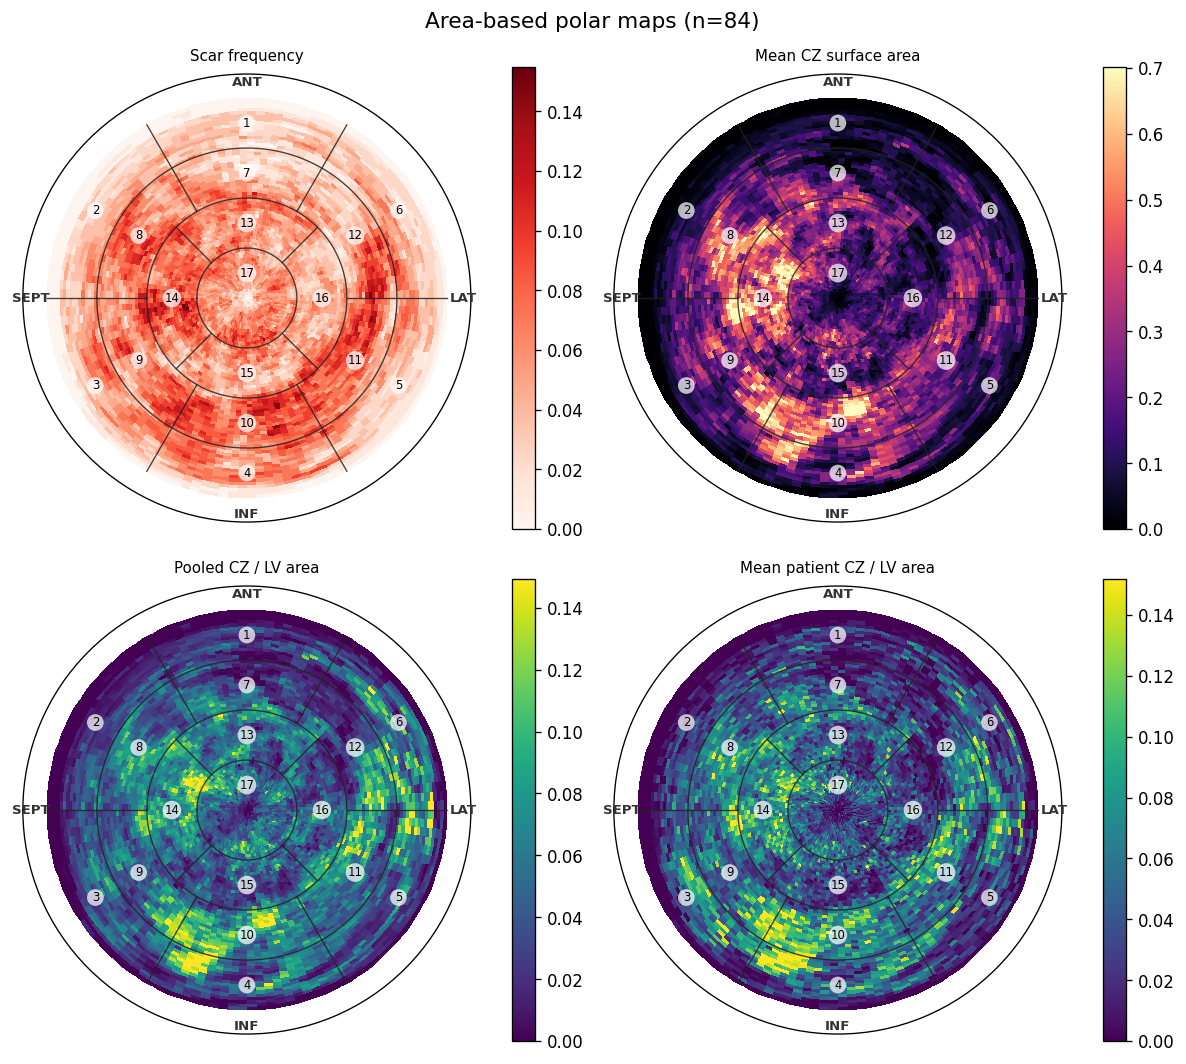

In [ ]:
def safe_divide(num, den):
    return np.divide(num, den, out=np.full_like(num, np.nan, dtype=float), where=den > EPS)


def build_population_maps(results):
    if not results:
        raise ValueError("No area_results available. Run the projection cell first.")

    keys = list(results.keys())
    cz_stack = np.stack([results[k]["cz_area"] for k in keys])
    lv_stack = np.stack([results[k]["lv_area"] for k in keys])
    coverage_stack = np.stack([results[k]["coverage"] for k in keys])

    scar_frequency = (cz_stack > EPS).mean(axis=0)
    mean_cz_area = cz_stack.mean(axis=0)
    pooled_coverage = safe_divide(cz_stack.sum(axis=0), lv_stack.sum(axis=0))

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        mean_patient_coverage = np.nanmean(coverage_stack, axis=0)

    return {
        "keys": keys,
        "cz_stack": cz_stack,
        "lv_stack": lv_stack,
        "coverage_stack": coverage_stack,
        "scar_frequency": scar_frequency,
        "mean_cz_area": mean_cz_area,
        "pooled_coverage": pooled_coverage,
        "mean_patient_coverage": mean_patient_coverage,
    }


pop = build_population_maps(area_results)

fig, axes = plt.subplots(2, 2, figsize=(10, 9), subplot_kw={"projection": "polar"})
axes = axes.ravel()

draw_bullseye(pop["scar_frequency"], axes[0], "Scar frequency", cmap="Reds", vmax=max(pop["scar_frequency"].max(), 0.01), label_segments=True, colorbar=True)
draw_bullseye(pop["mean_cz_area"], axes[1], "Mean CZ surface area", cmap="magma", label_segments=True, colorbar=True)
draw_bullseye(pop["pooled_coverage"], axes[2], "Pooled CZ / LV area", cmap="viridis", label_segments=True, colorbar=True)
draw_bullseye(pop["mean_patient_coverage"], axes[3], "Mean patient CZ / LV area", cmap="viridis", label_segments=True, colorbar=True)

fig.suptitle(f"Area-based polar maps (n={len(area_results)})", fontsize=13)
plt.tight_layout()
fig.savefig(OUT / "area_surface_population_maps.png", bbox_inches="tight", dpi=160)
plt.show()

## General Cohort Polar Map

This compact figure gives the main cohort-level view: scar frequency on the left and surface-normalized scar coverage on the right.

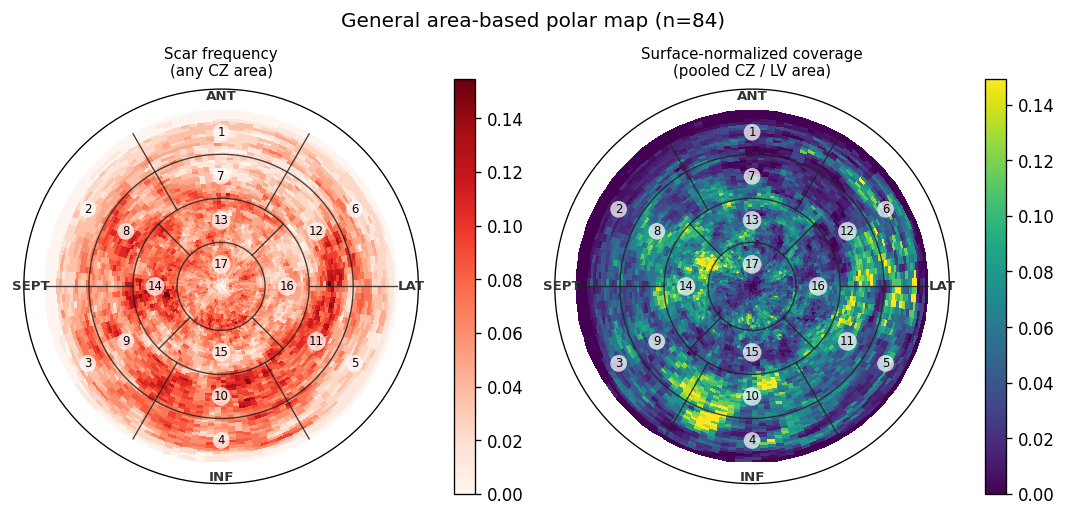

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4.4), subplot_kw={"projection": "polar"})

draw_bullseye(
    pop["scar_frequency"], axes[0],
    "Scar frequency\n(any CZ area)",
    cmap="Reds", vmax=max(pop["scar_frequency"].max(), 0.01),
    label_segments=True, colorbar=True,
)
draw_bullseye(
    pop["pooled_coverage"], axes[1],
    "Surface-normalized coverage\n(pooled CZ / LV area)",
    cmap="viridis", label_segments=True, colorbar=True,
)

fig.suptitle(f"General area-based polar map (n={len(area_results)})", fontsize=12)
plt.tight_layout()
fig.savefig(OUT / "general_area_surface_polar_map.png", bbox_inches="tight", dpi=180)
plt.show()

## Patient-Level Coverage Grid

This grid shows per-case `CZ area / LV area` coverage. It is useful for checking whether the normalization behaves sensibly before interpreting the population maps.

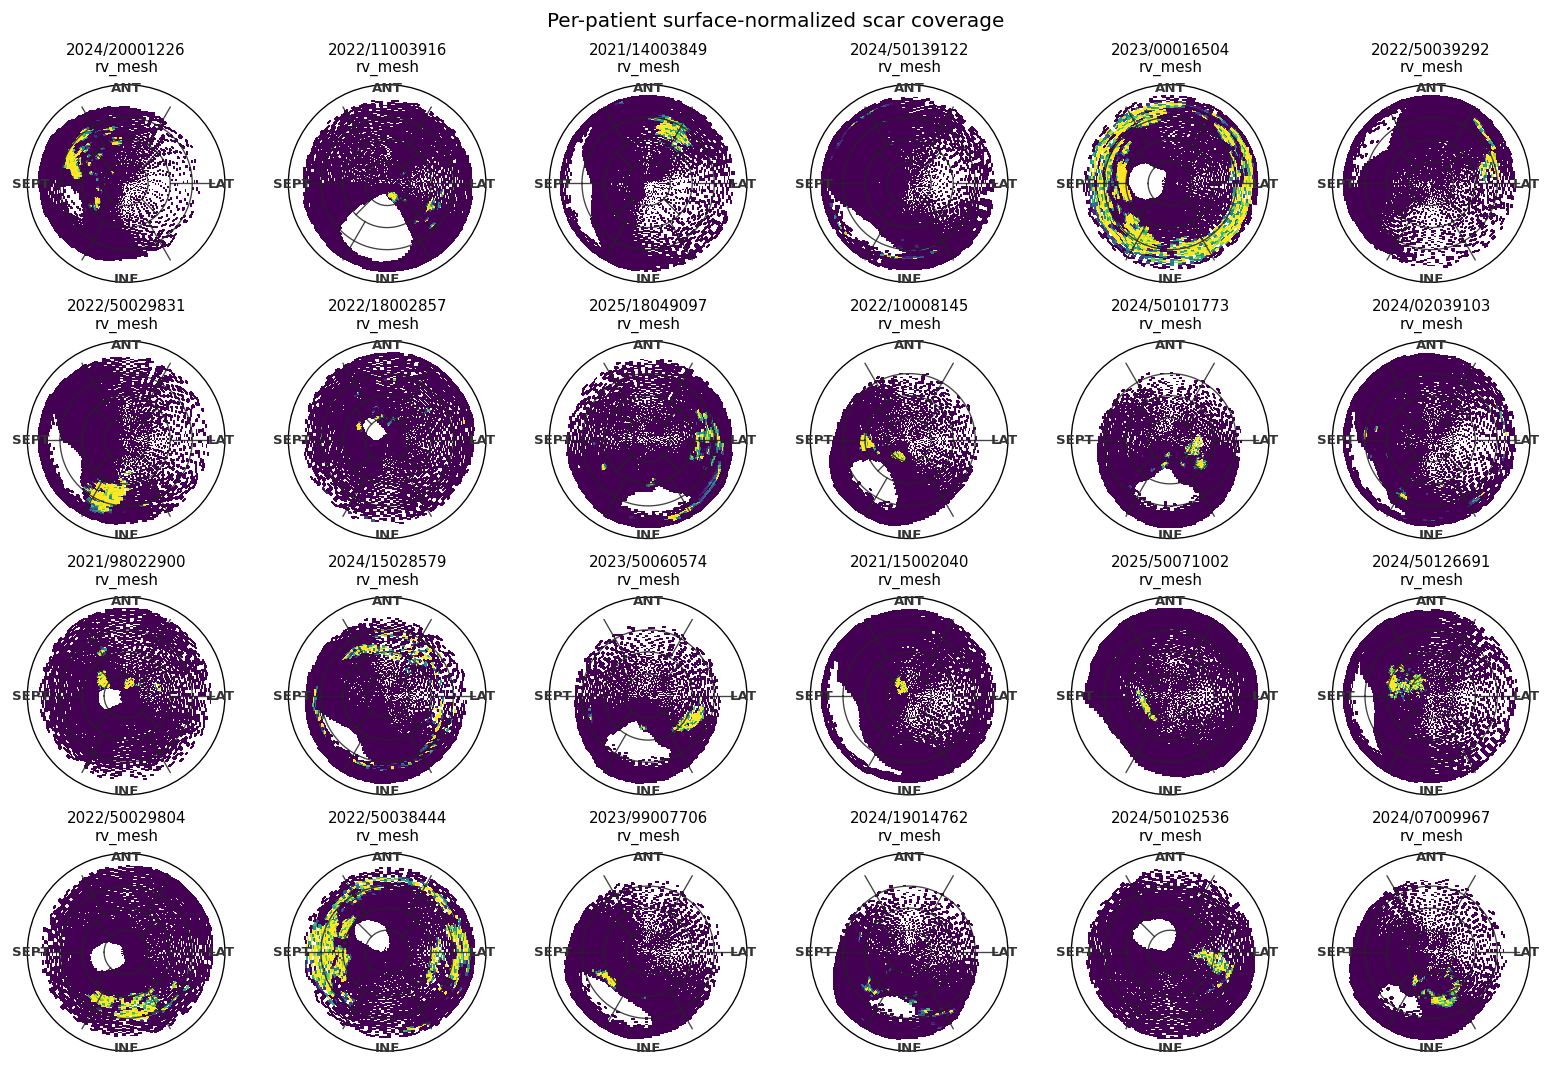

In [ ]:
def robust_vmax(values, percentile=98):
    finite = values[np.isfinite(values)]
    if finite.size == 0:
        return 1.0
    return max(float(np.nanpercentile(finite, percentile)), EPS)


if area_results:
    keys = list(area_results.keys())[:MAX_PATIENT_GRID]
    vmax_cov = robust_vmax(np.stack([area_results[k]["coverage"] for k in keys]), percentile=98)

    ncols = 6
    nrows = math.ceil(len(keys) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(2.2 * ncols, 2.25 * nrows), subplot_kw={"projection": "polar"})
    axes = np.atleast_1d(axes).ravel()

    for ax, key in zip(axes, keys):
        draw_bullseye(
            area_results[key]["coverage"], ax,
            title=f"{key}\n{area_results[key]['ref_method']}",
            cmap="viridis", vmax=vmax_cov, label_segments=False,
        )

    for ax in axes[len(keys):]:
        ax.axis("off")

    fig.suptitle("Per-patient surface-normalized scar coverage", fontsize=12)
    plt.tight_layout()
    fig.savefig(OUT / "patient_coverage_grid.png", bbox_inches="tight", dpi=160)
    plt.show()

## AHA and Ring Summaries

The same area maps can be summarized clinically by AHA-17 segment or by LV ring.

For every case and segment, the notebook computes:

- `cz_area`: total CZ surface area in the segment.
- `lv_area`: total LV shell surface area in the segment.
- `coverage`: `cz_area / lv_area`.
- `scar_present`: whether any CZ area was projected into the segment.

In [ ]:
SEGMENT_NAMES = {
    1: "basal anterior",
    2: "basal anteroseptal",
    3: "basal inferoseptal",
    4: "basal inferior",
    5: "basal inferolateral",
    6: "basal anterolateral",
    7: "mid anterior",
    8: "mid anteroseptal",
    9: "mid inferoseptal",
    10: "mid inferior",
    11: "mid inferolateral",
    12: "mid anterolateral",
    13: "apical anterior",
    14: "apical septal",
    15: "apical inferior",
    16: "apical lateral",
    17: "apex",
}


def _six_segment(theta_deg, basal=True):
    if 0 <= theta_deg < 60:
        return 2 if basal else 8
    if 60 <= theta_deg < 120:
        return 1 if basal else 7
    if 120 <= theta_deg < 180:
        return 6 if basal else 12
    if 180 <= theta_deg < 240:
        return 5 if basal else 11
    if 240 <= theta_deg < 300:
        return 4 if basal else 10
    return 3 if basal else 9


def _apical_segment(theta_deg):
    if 45 <= theta_deg < 135:
        return 13
    if 135 <= theta_deg < 225:
        return 16
    if 225 <= theta_deg < 315:
        return 15
    return 14


def aha_segment_grid(n_r=N_R, n_theta=N_THETA):
    labels = np.zeros((n_r, n_theta), dtype=np.int64)
    r_centers = (np.arange(n_r) + 0.5) / n_r
    theta_centers = (np.arange(n_theta) + 0.5) / n_theta * 360.0

    for ri, radius in enumerate(r_centers):
        for ti, theta_deg in enumerate(theta_centers):
            if radius < 0.25:
                labels[ri, ti] = 17
            elif radius < 0.50:
                labels[ri, ti] = _apical_segment(theta_deg)
            elif radius < 0.75:
                labels[ri, ti] = _six_segment(theta_deg, basal=False)
            else:
                labels[ri, ti] = _six_segment(theta_deg, basal=True)
    return labels


def ring_grid(n_r=N_R, n_theta=N_THETA):
    labels = np.empty((n_r, n_theta), dtype=object)
    r_centers = (np.arange(n_r) + 0.5) / n_r
    for ri, radius in enumerate(r_centers):
        if radius < 0.25:
            label = "apex"
        elif radius < 0.50:
            label = "apical"
        elif radius < 0.75:
            label = "mid"
        else:
            label = "basal"
        labels[ri, :] = label
    return labels


AHA_GRID = aha_segment_grid()
RING_GRID = ring_grid()

In [ ]:
def summarize_by_labels(results, label_grid, label_name="label"):
    rows = []
    labels = list(pd.unique(label_grid.ravel()))

    for key, result in results.items():
        for label in labels:
            mask = label_grid == label
            cz_area = float(np.nansum(result["cz_area"][mask]))
            lv_area = float(np.nansum(result["lv_area"][mask]))
            coverage = cz_area / lv_area if lv_area > EPS else np.nan
            rows.append({
                "case": key,
                label_name: label,
                "ref_method": result["ref_method"],
                "cz_area": cz_area,
                "lv_area": lv_area,
                "coverage": coverage,
                "scar_present": cz_area > EPS,
            })

    per_case = pd.DataFrame(rows)

    summary_rows = []
    for label, group in per_case.groupby(label_name, sort=True):
        pooled_den = group["lv_area"].sum()
        pooled_cov = group["cz_area"].sum() / pooled_den if pooled_den > EPS else np.nan
        summary_rows.append({
            label_name: label,
            "n_cases": int(len(group)),
            "scar_frequency": float(group["scar_present"].mean()),
            "mean_cz_area": float(group["cz_area"].mean()),
            "median_cz_area": float(group["cz_area"].median()),
            "mean_patient_coverage": float(group["coverage"].mean()),
            "median_patient_coverage": float(group["coverage"].median()),
            "pooled_coverage": float(pooled_cov),
        })

    summary = pd.DataFrame(summary_rows)
    return per_case, summary


per_case_aha, aha_summary = summarize_by_labels(area_results, AHA_GRID, label_name="segment")
aha_summary["segment_name"] = aha_summary["segment"].map(SEGMENT_NAMES)
aha_summary = aha_summary.sort_values("segment")

per_case_ring, ring_summary = summarize_by_labels(area_results, RING_GRID, label_name="ring")
ring_order = pd.CategoricalDtype(["apex", "apical", "mid", "basal"], ordered=True)
ring_summary["ring"] = ring_summary["ring"].astype(ring_order)
ring_summary = ring_summary.sort_values("ring")

per_case_aha.to_csv(OUT / "per_case_aha_area_coverage.csv", index=False)
aha_summary.to_csv(OUT / "aha_area_coverage_summary.csv", index=False)
per_case_ring.to_csv(OUT / "per_case_ring_area_coverage.csv", index=False)
ring_summary.to_csv(OUT / "ring_area_coverage_summary.csv", index=False)

display(aha_summary)
display(ring_summary)

,segment,n_cases,scar_frequency,mean_cz_area,median_cz_area,mean_patient_coverage,median_patient_coverage,pooled_coverage,segment_name
0,1,84,0.214286,20.598546,0.000000,0.019032,0.000000,0.021341,basal anterior
1,2,84,0.226190,29.206236,0.000000,0.034491,0.000000,0.025114,basal anteroseptal
2,3,84,0.321429,41.025240,0.000000,0.040695,0.000000,0.037155,basal inferoseptal
3,4,84,0.380952,74.378110,0.000000,0.052480,0.000000,0.053114,basal inferior
4,5,84,0.321429,42.913861,0.000000,0.038027,0.000000,0.046554,basal inferolateral
5,6,84,0.285714,34.874532,0.000000,0.031201,0.000000,0.052264,basal anterolateral
6,7,84,0.428571,61.043881,0.000000,0.037618,0.000000,0.040104,mid anterior
7,8,84,0.488095,116.931107,0.000000,0.056791,0.000000,0.059831,mid anteroseptal
8,9,84,0.571429,113.280334,2.891162,0.059346,0.001047,0.057913,mid inferoseptal
9,10,84,0.464286,144.551822,0.000000,0.082210,0.000000,0.080496,mid inferior


,ring,n_cases,scar_frequency,mean_cz_area,median_cz_area,mean_patient_coverage,median_patient_coverage,pooled_coverage
0,apex,84,0.630952,321.284330,40.521538,0.046303,0.004562,0.047638
1,apical,84,0.892857,557.319729,179.035922,0.053957,0.018148,0.057183
3,mid,84,0.892857,570.808686,310.193918,0.058267,0.037280,0.059278
2,basal,84,0.630952,242.996525,11.488883,0.035579,0.001517,0.039056


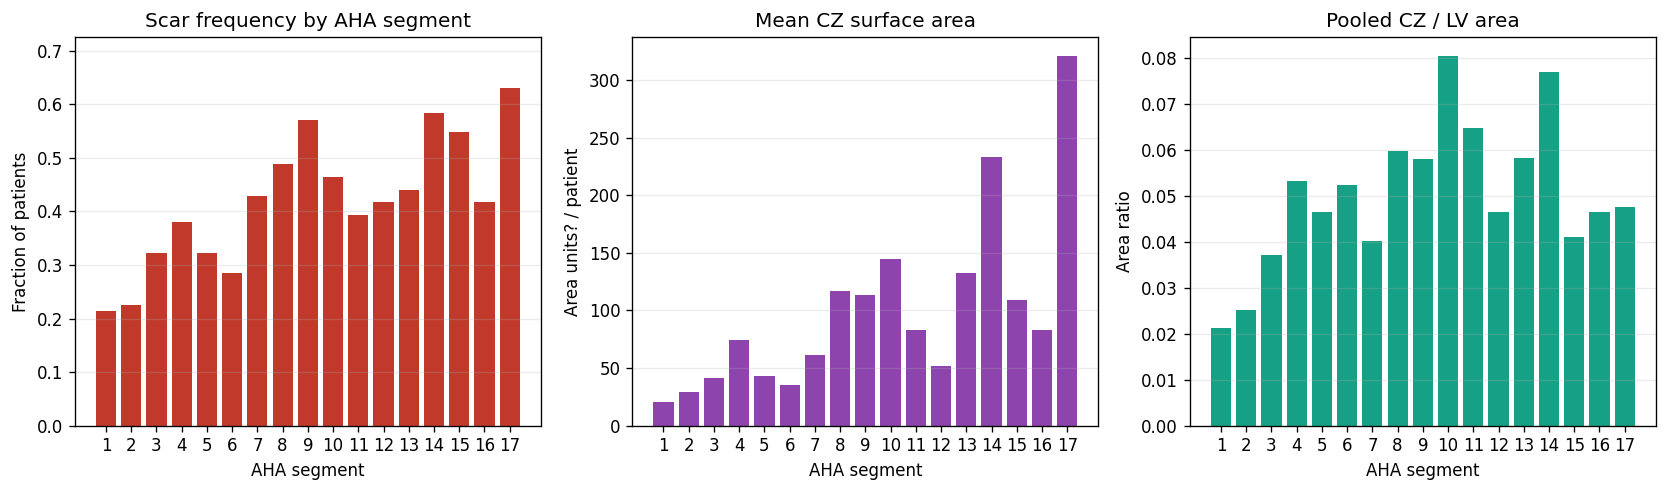

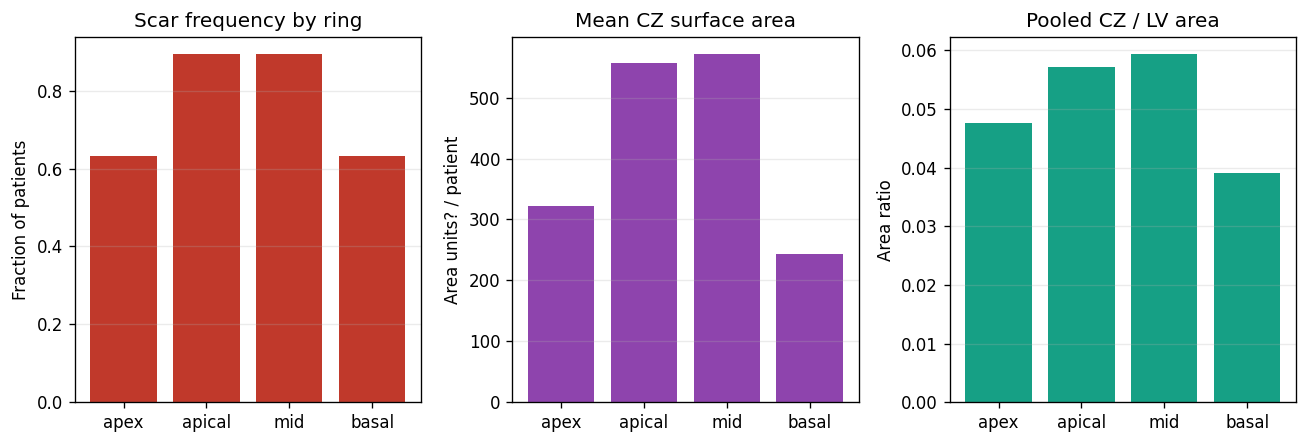

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

x = aha_summary["segment"].astype(int)
axes[0].bar(x, aha_summary["scar_frequency"], color="#c0392b")
axes[0].set_title("Scar frequency by AHA segment")
axes[0].set_xlabel("AHA segment")
axes[0].set_ylabel("Fraction of patients")
axes[0].set_xticks(range(1, 18))
axes[0].set_ylim(0, max(0.05, aha_summary["scar_frequency"].max() * 1.15))

axes[1].bar(x, aha_summary["mean_cz_area"], color="#8e44ad")
axes[1].set_title("Mean CZ surface area")
axes[1].set_xlabel("AHA segment")
axes[1].set_ylabel("Area units? / patient")
axes[1].set_xticks(range(1, 18))

axes[2].bar(x, aha_summary["pooled_coverage"], color="#16a085")
axes[2].set_title("Pooled CZ / LV area")
axes[2].set_xlabel("AHA segment")
axes[2].set_ylabel("Area ratio")
axes[2].set_xticks(range(1, 18))

for ax in axes:
    ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
fig.savefig(OUT / "aha_area_coverage_summary.png", bbox_inches="tight", dpi=160)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(11, 3.8))
rx = ring_summary["ring"].astype(str)

axes[0].bar(rx, ring_summary["scar_frequency"], color="#c0392b")
axes[0].set_title("Scar frequency by ring")
axes[0].set_ylabel("Fraction of patients")

axes[1].bar(rx, ring_summary["mean_cz_area"], color="#8e44ad")
axes[1].set_title("Mean CZ surface area")
axes[1].set_ylabel("Area units? / patient")

axes[2].bar(rx, ring_summary["pooled_coverage"], color="#16a085")
axes[2].set_title("Pooled CZ / LV area")
axes[2].set_ylabel("Area ratio")

for ax in axes:
    ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
fig.savefig(OUT / "ring_area_coverage_summary.png", bbox_inches="tight", dpi=160)
plt.show()

## Interpretation Notes

- `mean_cz_area` is an absolute surface-area map. It is useful for locating where scar area accumulates, but bins near the base naturally cover more physical LV surface than bins near the apex.
- `pooled_coverage` corrects for available LV surface area in each bin, so it is closer to a local scar burden map.
- `mean_patient_coverage` gives every patient equal weight after per-patient normalization.
- `scar_frequency` remains a patient-presence map: it asks how often scar appears in each bin, independent of area magnitude.

Important caveat: the CZ mesh is a scar surface exported by ADAS, not necessarily a one-to-one patch on the LV shell. Therefore `CZ area / LV shell area` should be interpreted as a normalized spatial scar-surface index, not as exact histological transmural scar fraction.